### Sales and Profit Analysis of Global Superstore

#### Objectives

- Which category generates the highest sales?
- Which category generates the highest profit?
- Which sub-category performs best in terms of sales and profit?
- Which region generates the highest sales and profit?
- How do sales and profit vary over time?
- How does discount affect profit?
- What is the relationship between sales and profit?
- Which products are the top performers by sales?
- What factors influence profit and sales performance?
- Which category performs best overall when considering multiple metrics?

In [1]:
#Importing libraries
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\hp\Downloads\sales_analysis_dataset.csv")

In [3]:
df.head(2)

,Order_ID,Order_Date,Region,Category,Sub_Category,Product_Name,Sales,Profit,Discount,Quantity
0,1001,2022-10-13,East,Office Supplies,Binders,Binders Product 44,144.55,13.51,0.1,9
1,1002,2023-04-22,East,Furniture,Bookcases,Bookcases Product 36,2121.17,165.68,0.0,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      1000 non-null   int64  
 1   Order_Date    1000 non-null   str    
 2   Region        1000 non-null   str    
 3   Category      1000 non-null   str    
 4   Sub_Category  1000 non-null   str    
 5   Product_Name  1000 non-null   str    
 6   Sales         1000 non-null   float64
 7   Profit        1000 non-null   float64
 8   Discount      1000 non-null   float64
 9   Quantity      1000 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 78.3 KB


In [5]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Region          0
Category        0
Sub_Category    0
Product_Name    0
Sales           0
Profit          0
Discount        0
Quantity        0
dtype: int64

In [6]:
df.describe

<bound method NDFrame.describe of      Order_ID  Order_Date   Region         Category Sub_Category  \
0        1001  2022-10-13     East  Office Supplies      Binders   
1        1002  2023-04-22     East        Furniture    Bookcases   
2        1003  2023-07-24     East  Office Supplies      Storage   
3        1004  2023-11-21     East  Office Supplies        Paper   
4        1005  2022-03-30  Central        Furniture       Tables   
..        ...         ...      ...              ...          ...   
995      1996  2022-01-26     East       Technology      Copiers   
996      1997  2024-09-12  Central  Office Supplies      Binders   
997      1998  2024-11-16    South        Furniture       Chairs   
998      1999  2023-08-20    South  Office Supplies      Binders   
999      2000  2022-04-22  Central  Office Supplies      Storage   

             Product_Name    Sales  Profit  Discount  Quantity  
0      Binders Product 44   144.55   13.51      0.10         9  
1    Bookcases Prod

In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Profit', 'Discount', 'Quantity'],
      dtype='str')

### Analyzing Dataset

In [8]:
#1.Which category generates the highest sales?
df.groupby('Category').agg({'Sales':'sum'}).sort_values(by='Sales',ascending=False).head(1)

,Sales
Category,
Furniture,856818.83


In [9]:
#2.Which category generates the highest profit?
df.groupby('Category').agg({'Profit':'sum'}).sort_values(by='Profit',ascending=False).head(1)

,Profit
Category,
Furniture,135996.8


In [10]:
#3.Which sub-category performs best in terms of sales and profit?
df.groupby('Sub_Category').agg({'Sales':'sum','Profit':'sum'}).sort_values(by = ['Sales','Profit'],ascending=False).head(1)

,Sales,Profit
Sub_Category,,
Tables,333690.06,51332.82


In [11]:

df.groupby('Region').agg({'Sales':'sum','Profit':'sum'}).sort_values(by = ['Sales','Profit'],ascending=False).head(1)

,Sales,Profit
Region,,
South,673157.47,110401.64


In [12]:
#5.How do sales and profit vary over time?
df.groupby(['Order_Date']).agg({'Sales':'sum','Profit':'sum'}).sort_index()

,Sales,Profit
Order_Date,,
2022-01-02,4648.58,778.11
2022-01-03,4764.01,597.99
2022-01-06,3447.26,359.14
2022-01-08,6856.12,888.81
2022-01-10,4816.02,1367.34
...,...,...
2024-12-24,2389.83,406.14
2024-12-26,2391.64,547.32
2024-12-27,4151.21,904.75


In [13]:
#6How does discount affect profit?
df.groupby('Discount').agg({'Profit':'mean'})

,Profit
Discount,
0.00,457.974667
0.05,490.478580
0.10,378.115029
0.15,384.793415
0.20,362.080460
0.30,334.975926


In [14]:
#7.What is the relationship between sales and profit?
df[['Sales','Profit']].corr()

,Sales,Profit
Sales,1.000000,0.695101
Profit,0.695101,1.000000


In [15]:
#8.Which products are the top performers by sales?
df.groupby('Product_Name').agg({'Sales':'sum','Profit':'sum'}).sort_values(by='Sales',ascending=False).head(5)

,Sales,Profit
Product_Name,,
Accessories Product 45,21199.01,3781.73
Binders Product 12,18572.17,3872.53
Binders Product 27,18450.51,3111.75
Paper Product 3,18245.70,2549.57
Chairs Product 35,18007.31,3115.67


In [16]:
#Which products are the top performers by sales?
df.groupby('Product_Name').agg({'Sales':'sum','Profit':'sum'}).sort_values(by='Sales',ascending=False).tail(5)

,Sales,Profit
Product_Name,,
Binders Product 19,82.48,23.41
Accessories Product 6,59.17,16.76
Chairs Product 22,51.76,0.63
Bookcases Product 8,34.12,11.30
Copiers Product 5,32.32,-0.39


In [17]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Profit', 'Discount', 'Quantity'],
      dtype='str')

In [18]:
#9.What factors influence profit and sales performance?
df[['Sales','Profit','Discount','Quantity']].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.695101,-0.003312,0.000025
Profit,0.695101,1.000000,-0.138557,0.012427
Discount,-0.003312,-0.138557,1.000000,-0.058591
Quantity,0.000025,0.012427,-0.058591,1.000000


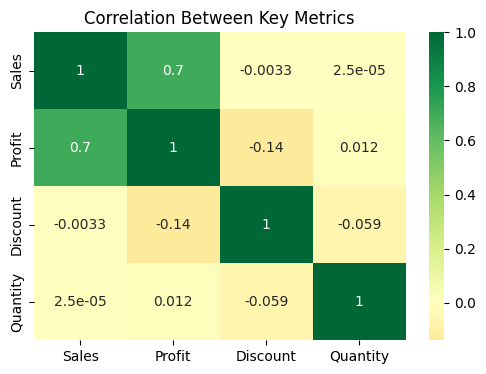

In [24]:
corr = df[['Sales','Profit','Discount','Quantity']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title("Correlation Between Key Metrics")
plt.show()

In [20]:
#10.Which category performs best overall when considering multiple metrics?
df.groupby('Category').agg({'Sales':'sum','Profit':'sum','Quantity':'sum','Discount':'mean'
                           }).sort_values(by='Profit', ascending=False)

,Sales,Profit,Quantity,Discount
Category,,,,
Furniture,856818.83,135996.80,1851,0.132827
Office Supplies,803444.48,132739.73,1928,0.128717
Technology,831165.22,132074.94,1837,0.138872


In [21]:
df.to_csv("cleaned_data.csv", index=False)